
<center><font size=10>Health Insurance Premium Prediction</center></font>


<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQXwCc0Mc7i0MRoBNNlcggRoW2_Ou7kQ6AYQAfYS6E0btjg6MemqRIijdz7&s=10" width="720"/>
</p></center>


# **Problem Statement**

## Business Context

Business Context

• Rising healthcare costs have increased the demand for affordable health insurance.

• Insurance companies need accurate premium prediction to set fair and competitive prices.

• Factors such as age, BMI, smoking status, and demographic information significantly influence insurance charges.

• Predictive analytics helps insurers estimate premiums accurately and improve risk assessment.

• Accurate premium prediction supports better pricing decisions, customer satisfaction, and long-term business profitability.

## Objective

Objective

The objective of this study is to develop a machine learning model that accurately predicts health insurance charges using personal and demographic information such as age, BMI, and smoking status. The model identifies the key factors influencing insurance premiums and evaluates its performance using metrics like Mean Squared Error (MSE) and R-squared (R²). The insights generated help insurance companies improve risk assessment, optimize premium pricing, and make data-driven business decisions.

## Data Description


The dataset consists of several key attributes:

- **Age**: Numerical value representing the age of the insured individual.
- **Sex**: Categorical variable indicating gender (male or female).
- **BMI**: Numerical value reflecting the Body Mass Index, a measure of body fat based on height and weight.
- **Children**: Numerical value representing the number of dependent children covered by the insurance policy.
- **Smoker**: Categorical variable indicating whether the individual is a smoker (yes or no).
- **Region**: Categorical variable that identifies the geographic area of the insured (southwest, southeast, northwest, northeast).
- **Charges**: Numerical value indicating the annual insurance premium (in USD) incurred by the policyholder.

This dataset contains a diverse range of cases, facilitating the modeling of different demographic and health profiles to predict insurance charges effectively.

# **Installing and Importing Necessary Libraries**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

These libraries are essential for various data science tasks in this notebook:

*   **`pandas` (pd)**: Used for data manipulation and analysis, particularly for handling DataFrames.
*   **`numpy` (np)**: Provides support for numerical operations, especially with arrays and mathematical functions.
*   **`matplotlib.pyplot` (plt)**: A plotting library used for creating static, interactive, and animated visualizations in Python.
*   **`seaborn` (sns)**: Built on top of Matplotlib, it's used for making statistical graphics more attractive and informative.
*   **`LinearRegression`**: From `sklearn.linear_model`, this is the core algorithm for building our linear regression models.
*   **`mean_squared_error`, `r2_score`**: From `sklearn.metrics`, these are used to evaluate the performance of our regression models.
*   **`train_test_split`**: From `sklearn.model_selection`, this utility helps split the dataset into training and testing subsets.
*   **`StandardScaler`, `OneHotEncoder`**: From `sklearn.preprocessing`, these are for scaling numerical features and encoding categorical features, respectively. (Although `OneHotEncoder` is not explicitly used here, `pd.get_dummies` achieves a similar effect and is commonly associated with this step in data preprocessing).

# **Loading the Data**


• The insurance dataset was loaded successfully using the Pandas library for analysis.

• The dataset contains customer information such as age, gender, BMI, number of children, smoking status, region, and insurance charges.

• Loading the dataset helps us understand its structure, features, and overall data quality before preprocessing.

• This dataset serves as the foundation for exploratory data analysis, model training, and health insurance charge prediction.

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/insurance_prediction.csv')


- The CSV file can also be directly loaded from Google Drive.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Load the dataset
#data = pd.read_csv('/content/drive/insurance_prediction.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Overview**

First, let's get a general understanding of our dataset. This includes looking at the first few rows, checking data types, identifying missing values, and summarizing descriptive statistics.

In [ ]:
data.shape

(1338, 7)

The dataset consists of 1,338 rows and 7 columns

In [ ]:
print(data.head(10))


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692


**Note:** If the generated code is not displaying the data in a tabular format. To ensure it appears as a table, simply remove the `print` statement from commands like `print(df.head(10))` to  `df.head(10)`.

In [ ]:
data.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


The `data.tail(10)` command is used to **display the last 10 rows** of the DataFrame named `data`.



The code provides a summary of the DataFrame, including the number of non-null entries, data types, and memory usage.


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **7 columns** and **1338 rows**, with **no missing values**.
- Data types are as expected:  
  - **Numeric:** `age`, `bmi`, `children`, `charges`  
  - **Categorical:** `sex`, `smoker`, `region`

We conclude there are no missing rows in the DataFrame as all columns have 1338 non-null entries, matching the total number of records.

In [ ]:
data.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Note**: To make the visualization easier to interpret, we can also transpose the data by appending `.T` at the end.

In [ ]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Observations:**
1. **Age:** The average age is **39.21 years**, with values ranging from **18 to 64**, indicating a broad adult age group.

2. **BMI:** The mean BMI is **30.66**, suggesting that the **average individual is classified as obese**.

3. **Children:** On average, individuals have **about 1 child**, with most having between **0 and 2 children**.

4. **Charges:** The **average medical charge is 13,270.42**, but the high standard deviation indicates **large variability** in healthcare costs.



The current summary displays only the numerical columns. Now, let’s move on to explore the summary of the categorical features.

In [ ]:
data.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


1. **Gender:** The dataset has a nearly balanced gender distribution, with **male** being slightly more frequent (676 out of 1338).  
2. **Smoking Status:** **Non-smokers** dominate the dataset (1064 entries), which could impact charge predictions.  
3. **Region:** The **southeast** region has the highest number of entries (364), making it the most represented geographic area.

In [ ]:
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
duplicate_rows


Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (1337, 7)


There were originally 1,338 rows. After removing 1 duplicate record, the dataset now contains 1,337 records.

# **Exploratory Data Analysis**

EDA helps identify missing values, duplicate records, and outliers that may affect model performance.

It reveals patterns and relationships between different features and insurance charges.

The analysis identifies the most important factors influencing health insurance premium prediction.

These insights improve data preprocessing, feature selection, and the overall accuracy of the machine learning model.

## **Univariate Analysis**

Analyzing individual features to understand their distributions.

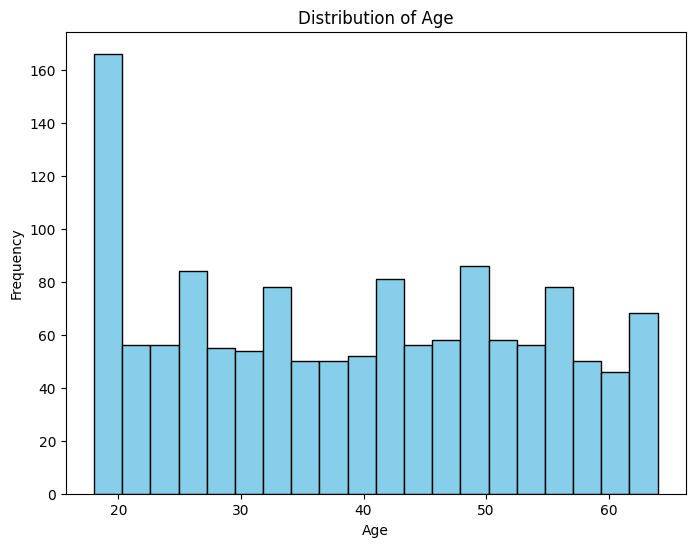

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


 Descriptive Statistics for Numerical Features

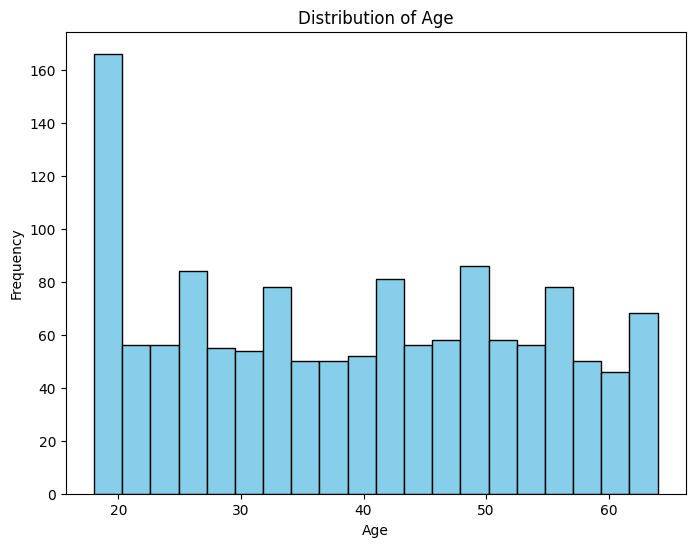

In [ ]:
# Create a histogram of the 'age' column
plt.figure(figsize=(8, 6))  # Set the figure size
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black') # Create histogram with 20 bins
plt.title('Distribution of Age') # Set the title of the histogram
plt.xlabel('Age') # Set the label for the x-axis
plt.ylabel('Frequency') # Set the label for the y-axis
plt.show() # Display the plot


**Observation**:
- From the chart, we can see that the **higher number of individuals in the lower age brackets** — particularly those around **20 to 25 years old**.
- This suggests that **younger individuals may be more aware of** or have greater access to **insurance** options.

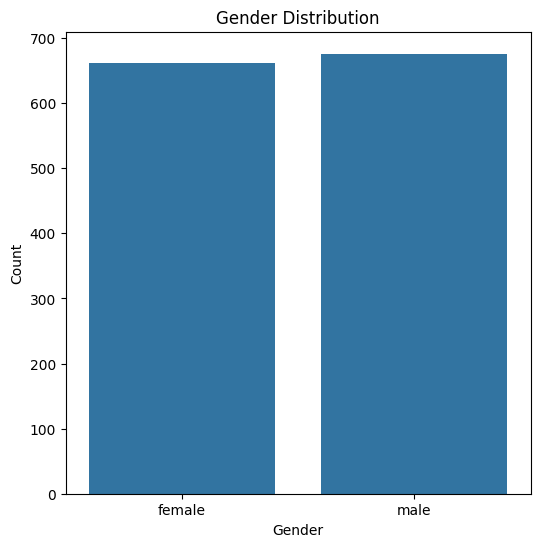

In [ ]:
# Check gender distribution to see if the data is balanced.
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


**Observation**:
- We can see that the gender distribution of the population is nearly balanced between males and females, suggesting equal interest in insurance across genders.

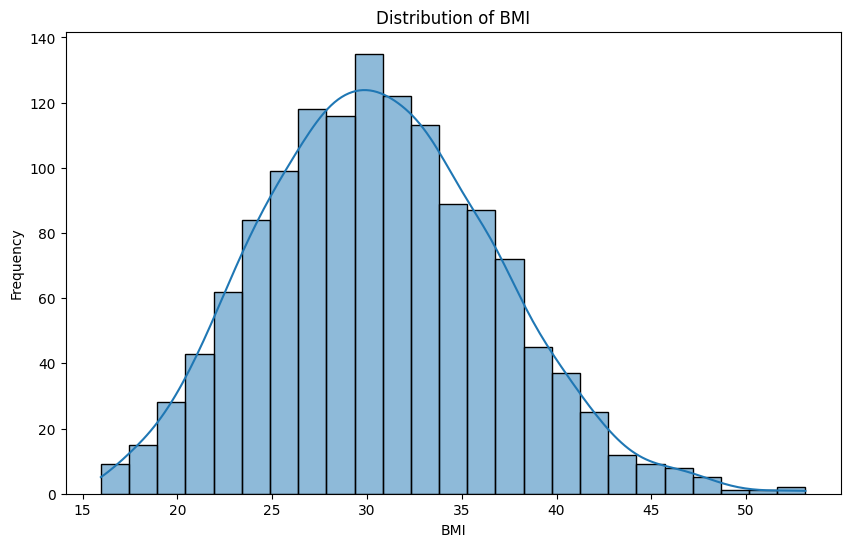

In [ ]:
# Analyze how BMI varies across individuals to detect obesity trends.
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True)#Kernel Density Estimation.
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


**Observations:**
- The data shows that most of the population has a BMI concentrated around 30, as evidenced by the peak of the distribution curve near this value. The bell-shaped curve with a slight right skew suggests a general trend toward higher body mass, with a few individuals having significantly higher BMI values (above 45), indicating the presence of outliers.


**NOTE** : The age distribution is displayed as a basic histogram, while the BMI distribution includes both a histogram and a KDE (smooth density) curve. This shows that Large Language Models (LLMs) can generate different chart styles for similar tasks. Therefore, it is important to clearly specify the required chart type to ensure consistent and accurate visualizations.

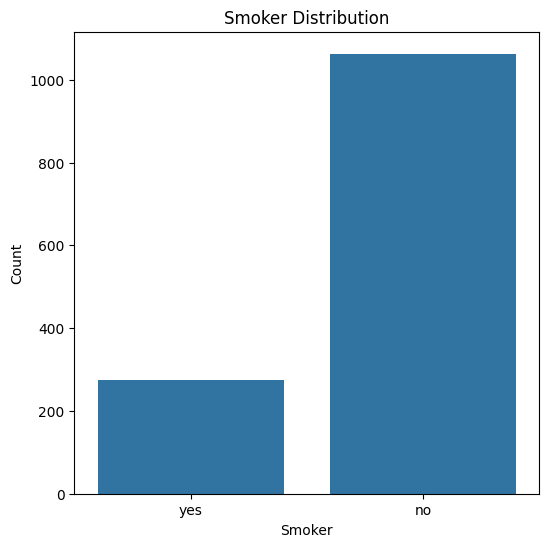

In [ ]:
# Visualize the distribution of smokers in the data.
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoker Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()


**Observations:**
- The majority of the population appears to be non-smokers.
- This indicates that smoking status could be a key factor in health insurance assessments.

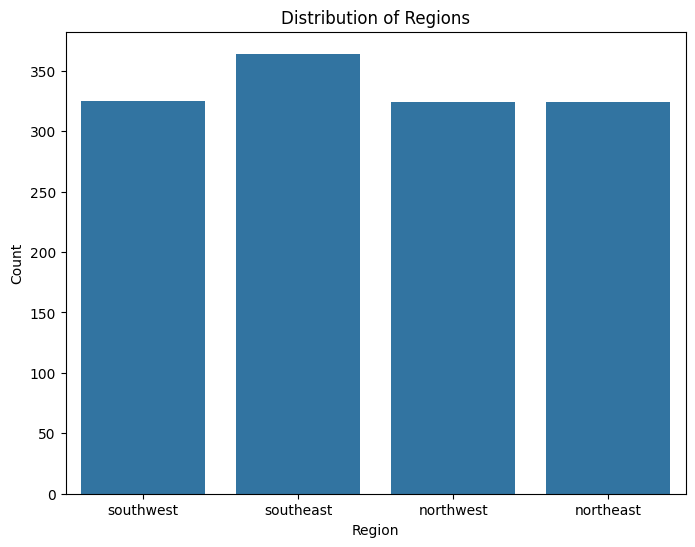

In [ ]:
# Visualize the distribution of regions in the data.
plt.figure(figsize=(8, 6))
sns.countplot(x='region', data=data)
plt.title('Distribution of Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()


**Observations:**
- The regional distribution of individuals is relatively balanced, though the southeast has a slightly higher concentration. This suggests potential regional influences that may be important for targeted outreach or service planning.

**NOTE** : We specifically mention a box plot in the prompt to analyze charges, as it effectively displays the spread, highlights the median, and reveals skewness and outliers.

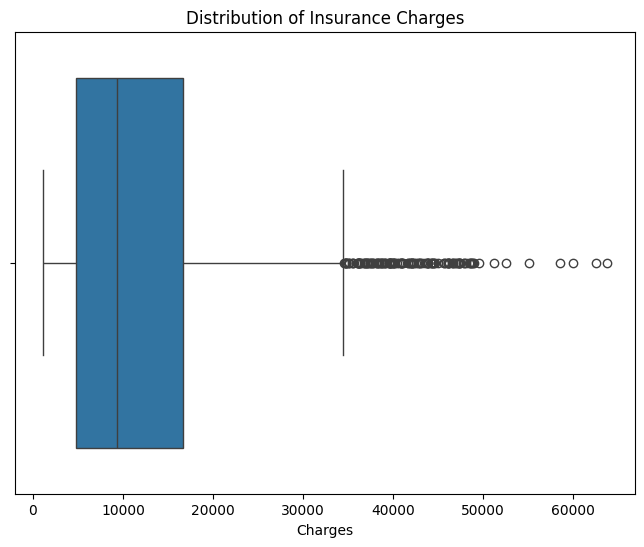

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='charges', data=data)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()


**Observations:**
- The boxplot shows that **most insurance charges fall below approximately 20,000**, with the **median around 9,000**. However, there are a **significant number of outliers** beyond 35,000, indicating that some individuals incur **very high medical costs**. This right-skewed distribution suggests a need for special attention to these high-cost cases when building predictive models or setting premium strategies.

## **Bivariate Analysis**

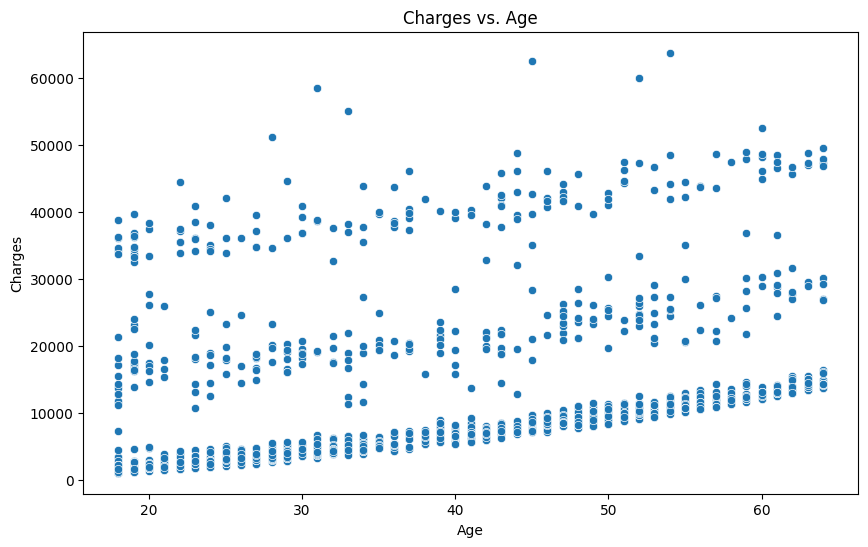

In [ ]:
# Create a scatter plot to visualize the relationship between age and charges.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


**Observations:**
- Insurance charges generally rise with age, indicating a positive correlation where older individuals tend to incur higher costs.
- The chart suggests the presence of three distinct clusters, possibly indicating different insurance plan

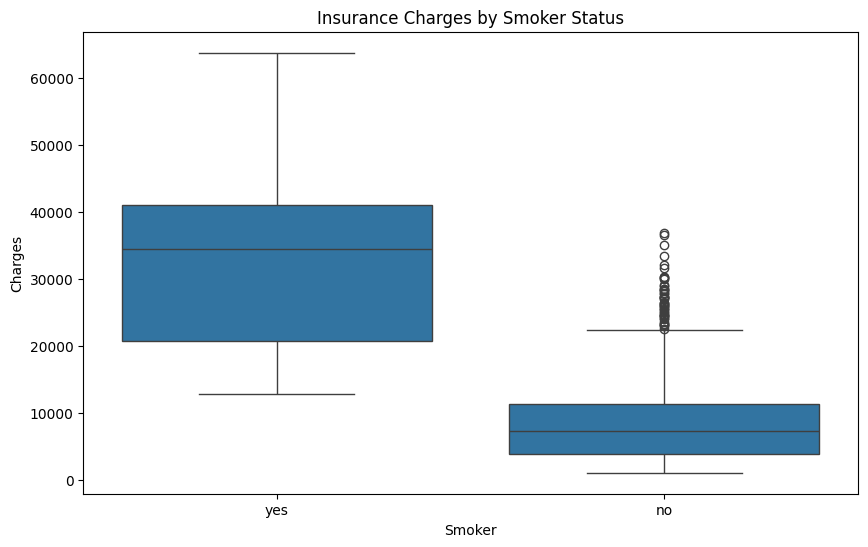

In [ ]:
# Compare charges for smokers vs. non-smokers
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()


**Observations:**

The boxplot shows that smokers have significantly higher insurance charges than non-smokers. It also indicates greater variation in charges among smokers, reflecting higher health risk. This strong difference confirms that smoking status is a key factor influencing health insurance premium prediction.

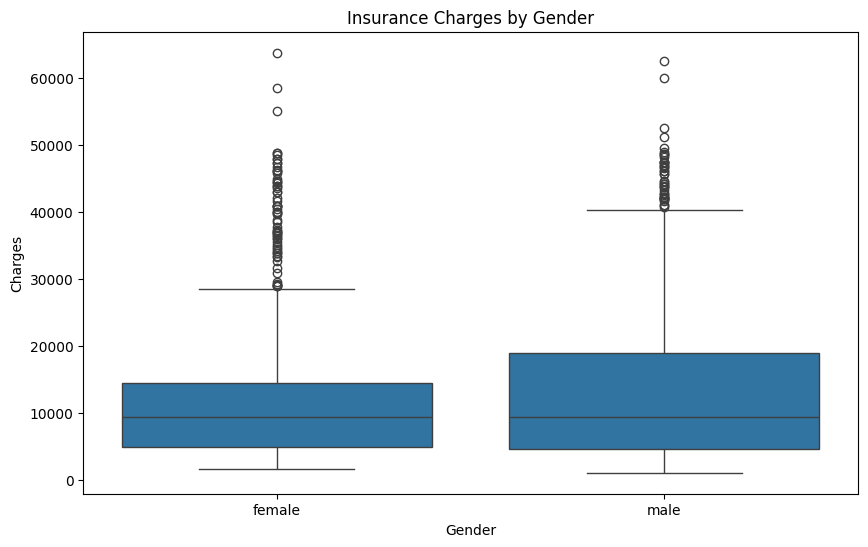

In [ ]:
# Analyze if gender affects charges.
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The box plot shows that males generally face higher and more variable insurance charges than females, suggesting gender may influence insurance pricing.
- This also prompts further investigation into whether other factors like **smoking status** or **BMI** are disproportionately associated with gender, which could be indirectly influencing the observed differences.

Compare charges across sex (male and female) and differentiate between smokers and non-smokers within each gender.

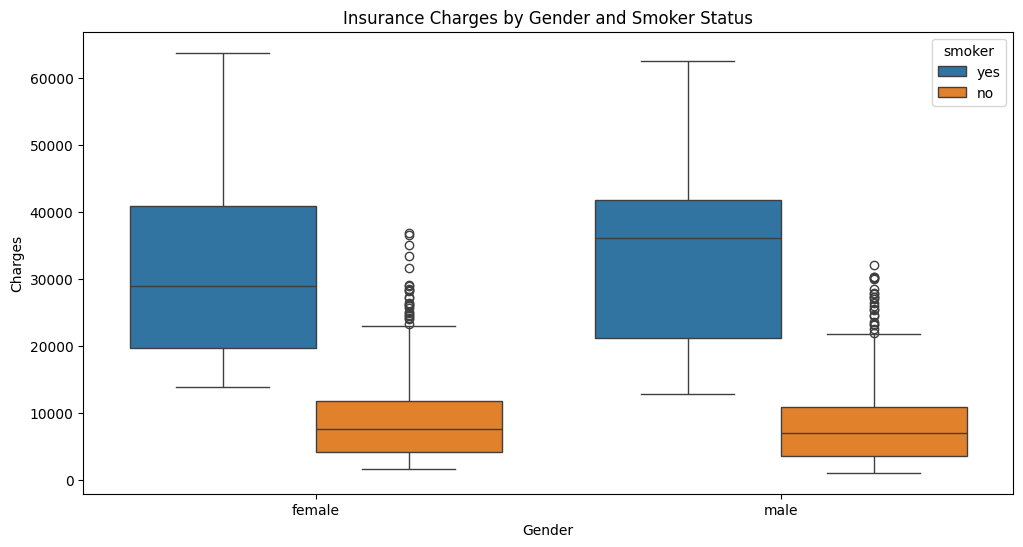

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- **Smokers** (both male and female) clearly have **significantly higher insurance charges** compared to non-smokers.
- Among **smokers**, **males** tend to have **slightly higher median charges** than females.
- For **non-smokers**, the distribution is similar across genders, but **male non-smokers show slightly more variability** in charges.


We plot the pair plot to visually explore relationships between key numerical features and see how smoking status affects insurance charges, as we can see a noticeable gap in charges between smokers and non-smokers.

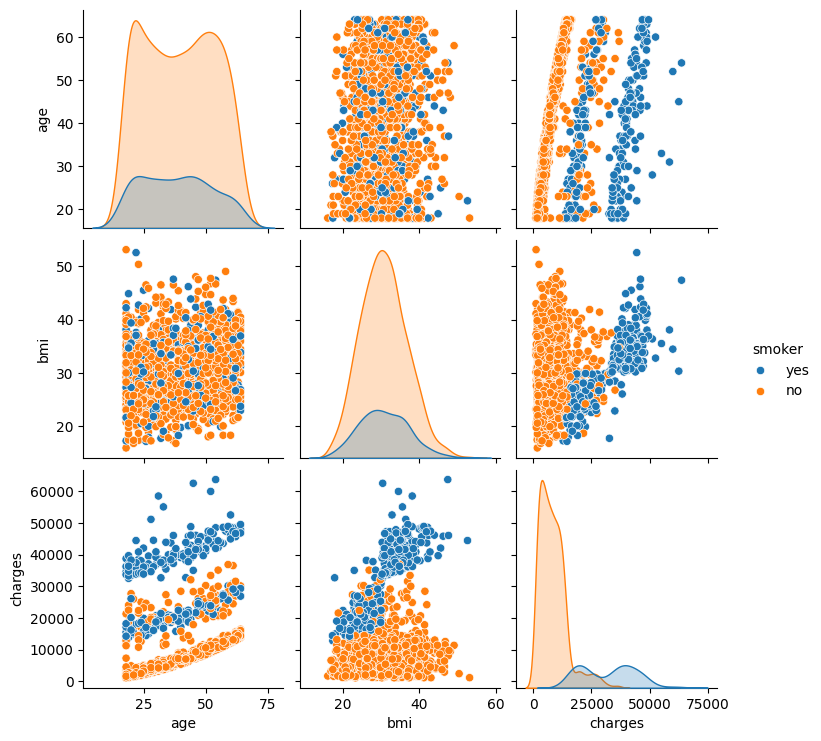

In [ ]:
# Create the pair plot
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()


**Observations:**

• Smokers have significantly higher insurance charges than non-smokers.

• Insurance charges generally increase as BMI increases, especially for smokers.

• Older individuals tend to have higher insurance charges, with a stronger effect among smokers.

• The age and BMI distributions are similar for both groups, but insurance charges are much higher and more variable for smokers.

Examine if having more children increases insurance charges.

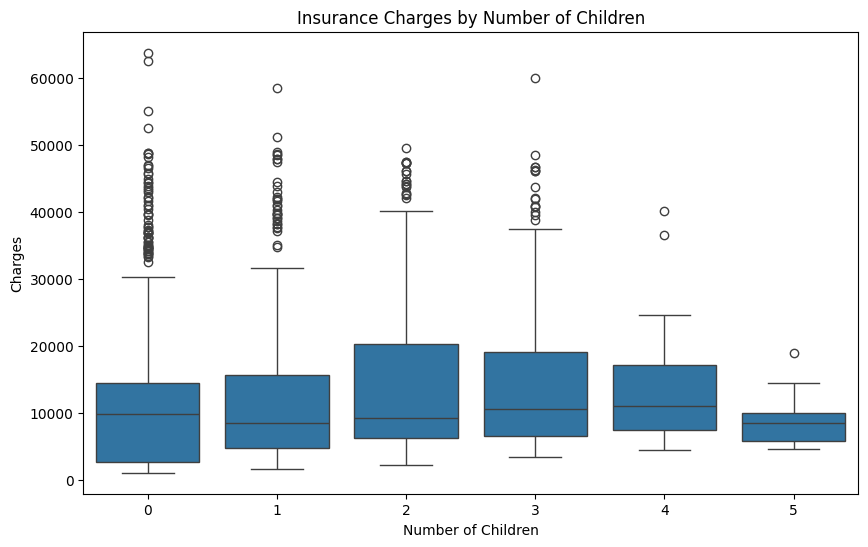

In [ ]:
# Analyze if the number of children influences charges.
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The box plot suggests that insurance charges increase with one or two children but plateau with three or more, indicating a limited impact of family size beyond a certain point.

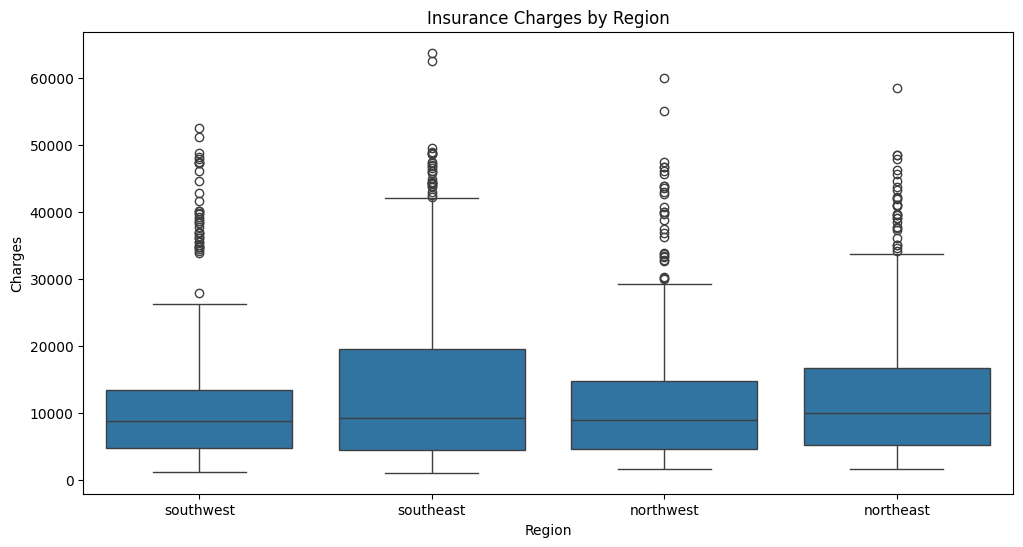

In [ ]:
# Analyze regional differences in charges.
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The boxplot shows that insurance charges are fairly consistent across regions, with **similar medians around 10,000**. However, the **Southeast region** stands out with the **widest spread (~15,000)** and a greater number of high-value outliers, suggesting more variability in charges there. Overall, region may not be a strong predictor of insurance cost, but the Southeast might warrant closer examination due to its higher dispersion.

We check the heatmap to interpret how strongly different features are related to the target variable and identify which factors may influence it the most.


This is a **correlation heatmap**, which shows how strongly numerical variables are related to each other.

- The values range from **-1 to 1**:
  - **1** means a **perfect positive relationship** (as one goes up, the other goes up).
  - **0** means **no relationship**.
  - **-1** means a **perfect negative relationship** (as one goes up, the other goes down).


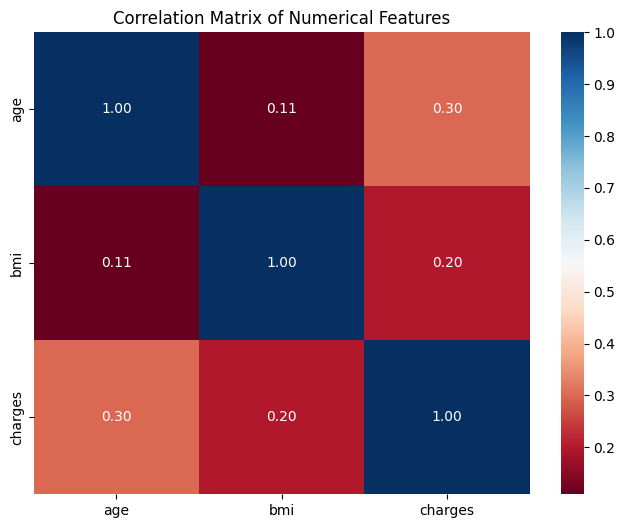

In [ ]:
# Create a correlation matrix for numerical features
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


**Observatios:**

- **Age vs Charges (0.30)**:  
   There’s a **moderate positive correlation**. This means that as people get older, their insurance charges tend to increase.

- **BMI vs Charges (0.20)**:  
   There’s a **weak positive correlation**. Higher BMI might lead to higher insurance charges, but the relationship isn't very strong.

- **Age vs BMI (0.11)**:  
   Almost **no correlation** — a person’s age doesn't really tell us much about their BMI.


# **Data Preprocessing**



Three Linear Regression models are developed to predict health insurance charges using different combinations of input features. Before training, categorical variables are encoded into numerical values, and the dataset is split into training and testing sets. This process ensures accurate model training and reliable performance evaluation.



• Model 1 uses only Age, Model 2 uses Age and BMI, and Model 3 uses all available features.

• Categorical variables such as sex, smoker, and region are converted into numerical format using encoding techniques.

• The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

### Encode the Data

**NOTE :** We use **dtype=int** in dummy encoding to guarantee that the output is numerical (0 and 1), as it may otherwise default to Boolean values (True and False).

In [ ]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)


We check the DataFrame to verify whether the data has been encoded correctly.

In [ ]:
data.head(10)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
5,31,25.740,0,3756.62160,0,0,0,1,0
6,46,33.440,1,8240.58960,0,0,0,1,0
7,37,27.740,3,7281.50560,0,0,1,0,0
8,37,29.830,2,6406.41070,1,0,0,0,0
9,60,25.840,0,28923.13692,0,0,1,0,0


### Train Test Split

In [ ]:
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (936, 8)
X_test shape: (402, 8)
y_train shape: (936,)
y_test shape: (402,)


The training and testing datasets are properly split, with approximately 70% of the data used for training and 30% for testing.

# **Model Building**

## Model Evaluation Criterion



Three Linear Regression models are developed to predict health insurance charges using different sets of input features. Categorical variables are encoded into numerical values, and the dataset is split into training and testing sets before model training. This process enables accurate prediction and reliable evaluation of the model's performance.


• Model 1 uses only Age, Model 2 uses Age and BMI, and Model 3 uses all available features.

• Categorical variables are converted into numerical format using encoding techniques.

• The dataset is divided into training and testing sets to assess the model's predictive performance on unseen data.

## Model Building



Linear Regression is used to predict health insurance charges by learning the relationship between the input features and the target variable. The model is trained using the preprocessed training dataset to understand how factors such as age, BMI, smoking status, and other features influence insurance charges.


• Linear Regression predicts continuous values such as insurance charges.

• The model learns the relationship between input features and the target variable during training.

• The trained model is then used to predict insurance charges for new or unseen data.

First, we create a blank DataFrame to store the training and testing metrics of different models.

In [ ]:
# prompt: Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### Model 1

In the first model, we use only the `age` feature to demonstrate how simple linear regression works and how it performs.

In [ ]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()

In [ ]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

Linear Regression Equation: Charges = 3673.84 + (247.60 * Age)


- Based on the above equation, we can say that insurance premium charges increase as the age of the customer increases.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

Now, let's evaluate the model's performance.

In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results

# Predict on training and testing data
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049


- The error is high and the R-squared value is low for both the training and testing datasets, indicating poor model performance and underfitting.
- This is likely due to the use of only a single feature and a simple linear model.

### Model 2

In the second model, we use only the numerical features to train a multiple linear regression model, and evaluate how well the model performs.

In [ ]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [ ]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


Linear Regression Equation: Charges = -5937.21 + (232.52 * Age) + (334.05 * BMI)


- Based on the above equation, we can say that insurance premium charges increase as the BMI of the customer increases, provided that the age is held constant.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

Now, let's check the model's performance.

In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049
1,Model 2 (Age and BMI),1.302894e+08,0.110461,1.273648e+08,0.131352


- The error has reduced slightly, but is still high, and the R-squared value is low for both the training and testing data, indicating that the model is still performing poorly and **underfitting**.


### Model 3

Now, we use the whole dataset, including both numerical and categorical features, to build our multiple linear regression model, and see how the model performs with all available information.

In [ ]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -12373.96 + (261.30 * age) + (348.91 * bmi) + (424.12 * children) + (104.81 * sex_male) + (23628.37 * smoker_yes) + (-486.93 * region_northwest) + (-970.97 * region_southeast) + (-926.32 * region_southwest)


In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049
1,Model 2 (Age and BMI),1.302894e+08,0.110461,1.273648e+08,0.131352
2,Model 3 (All Features),3.773055e+07,0.742398,3.378051e+07,0.769612


- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

## Model Comparison and Final Model Selecttion

In [ ]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049
1,Model 2 (Age and BMI),1.302894e+08,0.110461,1.273648e+08,0.131352
2,Model 3 (All Features),3.773055e+07,0.742398,3.378051e+07,0.769612


As we progress from Model 1 to Model 3, we observe a significant improvement in performance:

* **Model 1 (Age)** uses only a single feature and performs the worst, with a very high error and low R² values.
* **Model 2 (Age + BMI)** slightly improves both error and R², but still underperforms.
* **Model 3 (All Features)** shows a **drastic reduction in error** and a **substantial increase in R²**, indicating that it explains a much higher proportion of the variance in the target variable.

**Therefore, Model 3, which incorporates all available features, is the best performing model. It is selected as the final model due to its significantly better predictive accuracy and model fit.**

### Predict with the Best Model (Model 3) on Sample Data

In [ ]:
# Select a sample from the original data (e.g., first 5 rows)
sample_data = data.head(5).copy()

# Prepare the sample data for prediction (drop 'charges' column if present)
X_sample = sample_data.drop('charges', axis=1, errors='ignore')

# Make predictions using Model 3
sample_predictions = model_3.predict(X_sample)

# Add the predictions to the sample_data DataFrame for easy viewing
sample_data['predicted_charges'] = sample_predictions

# Display the sample data with actual and predicted charges
print("Sample Data with Actual and Predicted Charges:")
display(sample_data[['age', 'sex_male', 'smoker_yes', 'bmi', 'children', 'region_northwest', 'region_southeast', 'region_southwest', 'charges', 'predicted_charges']])

Sample Data with Actual and Predicted Charges:


,age,sex_male,smoker_yes,bmi,children,region_northwest,region_southeast,region_southwest,charges,predicted_charges
0,19,0,1,27.900,0,0,0,1,16884.92400,24527.647145
1,18,1,0,33.770,1,0,1,0,1725.55230,3569.296102
2,28,1,0,33.000,3,0,1,0,4449.46200,6873.213564
3,33,1,0,22.705,0,1,0,0,21984.47061,3652.627094
4,32,1,0,28.880,0,1,0,0,3866.85520,5429.146540


# **Business Recommendation**

1. **Targeted Premium Adjustments**  
   - Implement tiered pricing based on **age** and **BMI** to reflect varying risk levels more accurately.

2. **Smoking Cessation Incentives**  
   - Given the significant impact of smoking on insurance costs, consider offering discounts or wellness incentives to support non-smoking behavior and encourage a broader base of lower-risk customers.

3. **Wellness Programs**  
   - Introduce health programs to help policyholders manage BMI, which could lower both their charges and the company’s risk exposure.

4. **Region-Specific Strategies**  
   - Explore regional pricing only if operational costs or risk profiles justify it; otherwise, standard pricing may suffice.

5. **Marketing Focus**  
   - Target low-risk demographics—such as younger individuals, non-smokers, and those with healthy BMI—for affordable premium plans, while offering personalized support and coverage options for higher-risk segments.

<font size=6 color="navyblue">Power Ahead!</font>
___